## DBSCan clustering to identify outliers
Looking now at our Jupyter notebook, it's coming preloaded with the libraries you'll need. Those include pandas, Matplotlib, Seaborn, and scikit-learn. I've also given you the parameters for Matplotlib's data visualization and your Jupyter notebook is coming preloaded with the data that you need. 

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
from pylab import rcParams
import seaborn as sns

import sklearn
from sklearn.cluster import DBSCAN
from collections import Counter


In [2]:
%matplotlib inline
rcParams['figure.figsize'] = 5, 4
sns.set_style("whitegrid")

### DBSCan clustering to identify outliers
#### Train your model and identify outliers


In [3]:
df = pd.read_csv(filepath_or_buffer='../data/iris.data.csv', header=None, sep=',')

df.columns =[
    'sepal_length',
    'sepal_width',
    'petal_length',
    'petal_width',
    'species']

data = df.iloc[:,0:4].values

target = df.iloc[:,4].values

df[:5]


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### min distance between two samples for them to be considered as in the same neighborhood = 0.8 and the minimum number of samples in a neighborhood for a point to be considered as a core point = 19

In [4]:
model = DBSCAN(eps=0.8, min_samples=19).fit(data)

print(model)

DBSCAN(eps=0.8, min_samples=19)


In [5]:
outliers_df = pd.DataFrame(data)

print(Counter(model.labels_))
print(outliers_df[model.labels_ == -1])

Counter({1: 94, 0: 50, -1: 6})
       0    1    2    3
98   5.1  2.5  3.0  1.1
105  7.6  3.0  6.6  2.1
117  7.7  3.8  6.7  2.2
118  7.7  2.6  6.9  2.3
122  7.7  2.8  6.7  2.0
131  7.9  3.8  6.4  2.0


Text(0.5, 1.0, 'DBSCAN for Iris Dataset')

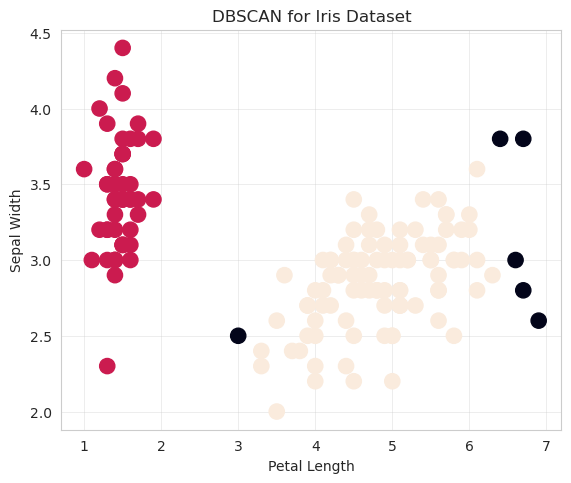

In [6]:
fig = plt.figure()

axis= fig.add_axes([.1,.1,1,1])

colors = model.labels_

#scatter plot of the data points with colors based on the cluster labels
axis.scatter(data[:,2], data[:,1], c=colors, s=120)
axis.set_xlabel('Petal Length')
axis.set_ylabel('Sepal Width')
plt.title('DBSCAN for Iris Dataset')